# SST (Small-Sized Telescope)

SST_like configuration with the CHEC-S camera style

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace import Camera, Telescope, show_camera, show_sensor_chain, show_telescope, show_image

## Load telescope and camera

In [12]:
telescope = Telescope.from_yaml(
    "../../configs/CTAO/SST_like.yaml",
    n_samples=256,
    key=jax.random.key(42),
)
camera = Camera.from_yaml("../../configs/CTAO/CHECS.yaml")

## 3D scene

In [3]:
scene = show_telescope(telescope, camera=camera)
scene.show(viewer="jupyter")

## Star field image

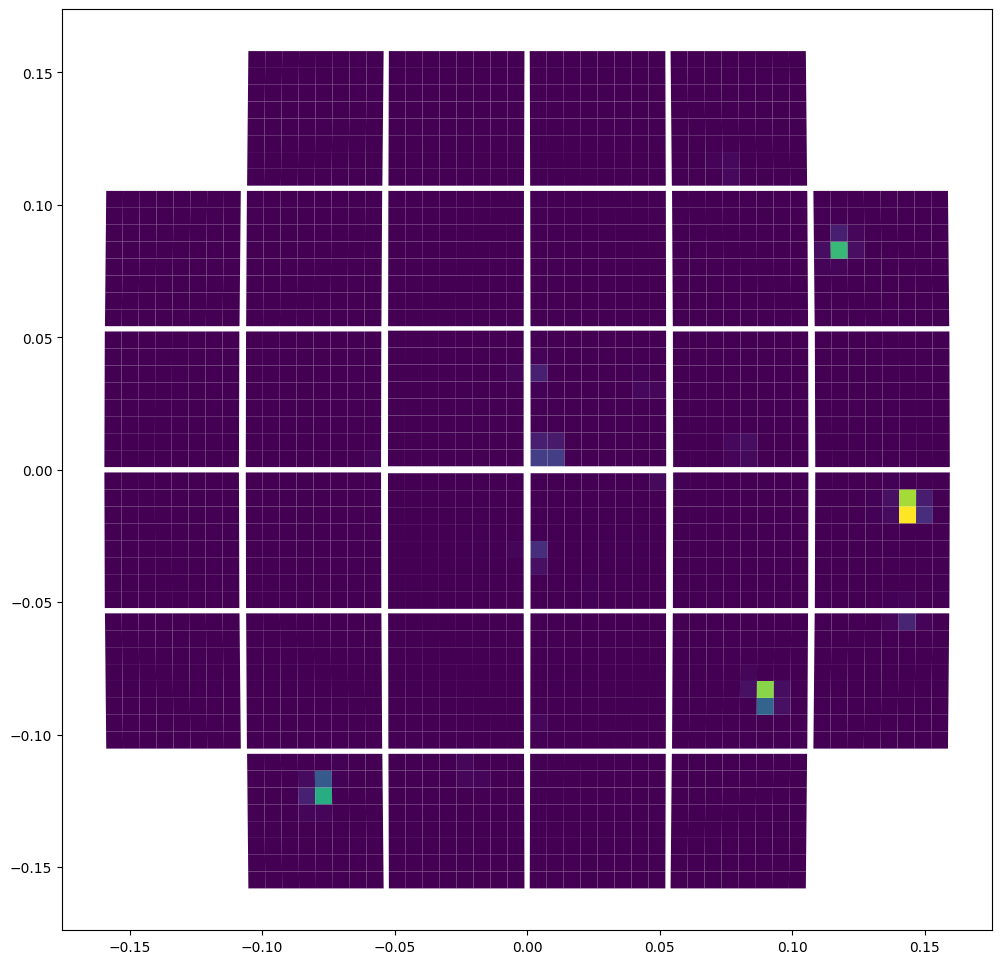

In [4]:
n_stars = 100
key1, key2 = jax.random.split(jax.random.key(42))

fov_deg = 7.7
fov_rad = fov_deg * jnp.pi / 180

x = jax.random.uniform(key1, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
y = jax.random.uniform(key2, (n_stars,), minval=-fov_rad / 2, maxval=fov_rad / 2)
z = -jnp.ones(n_stars)

stars = jnp.stack([x, y, z], axis=1)
stars = stars / jnp.linalg.norm(stars, axis=1, keepdims=True)

f_stars = 10 ** (-10 * jax.random.uniform(jax.random.key(4242), shape=(len(stars),)))

rays = telescope.render(stars, f_stars, source_type="parallel")
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_image(image, camera.sensor_groups[0], ax=ax)

## Bokeh from a finite-distance point source

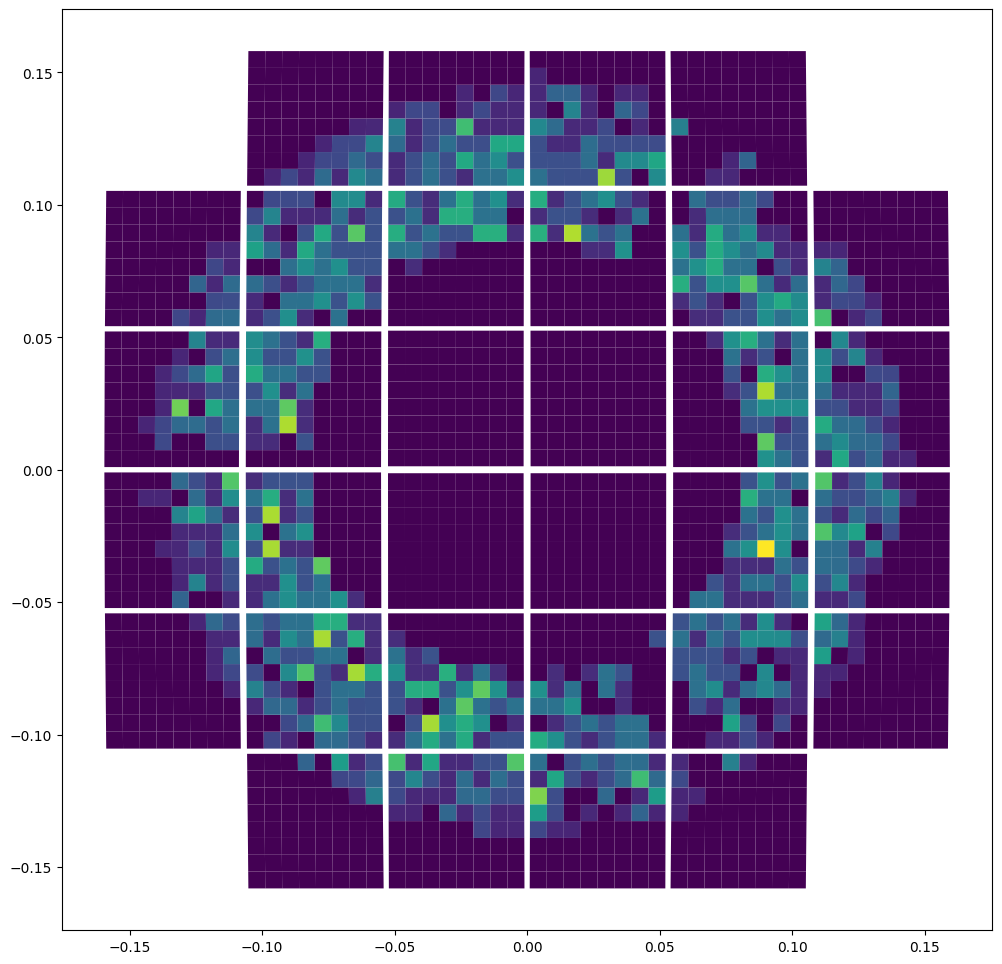

In [5]:
N_points = 1
key1, key2 = jax.random.split(jax.random.key(45))

x = jax.random.uniform(key1, N_points, minval=-0.1, maxval=0.1)
y = jax.random.uniform(key2, N_points, minval=-0.1, maxval=0.1)
z = jnp.ones(N_points) * 30

points = jnp.array([x, y, z]).T
f_points = jnp.ones(len(points))

rays = telescope.render(points, f_points, source_type="point")
image = camera.image(rays)

fig, ax = plt.subplots(ncols=1, figsize=(12, 12))
ax1 = show_image(image, camera.sensor_groups[0], ax=ax)

## Spot diagram

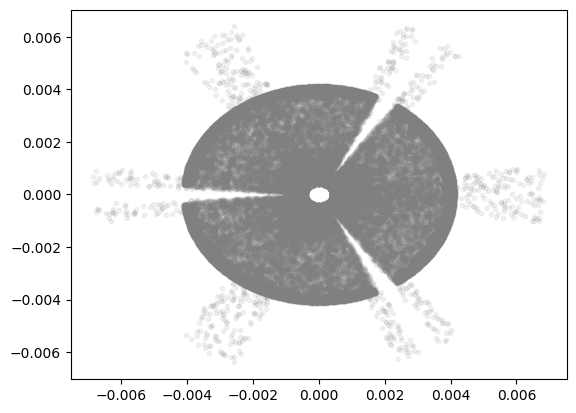

In [22]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

from iactrace.analysis import AsphericFocalSurface

stars = jnp.array([[0.00, 0.00, -1]])
stars = stars / jnp.linalg.norm(stars)
f_stars = jnp.array([1.0])
rays = telescope.render(stars, f_stars, source_type="parallel")

focal_plane = AsphericFocalSurface(curvature=-1 / 1.06)

hits = focal_plane.intersect(rays)
plt.scatter(
    hits.xy_local[hits.alive, 0], hits.xy_local[hits.alive, 1], alpha=0.1, color="gray", marker="."
)

## Visualizing trajectories

In [73]:
n_rays = 100
key1, key2 = jax.random.split(jax.random.key(123))

r = 2.5 * jnp.sqrt(jax.random.uniform(key1, (n_rays,)))
theta = jax.random.uniform(key2, (n_rays,)) * 2 * jnp.pi
ray_origins = jnp.stack(
    [r * jnp.cos(theta), r * jnp.sin(theta), jnp.ones(n_rays) * 5.0],
    axis=1,
)

tilt_angle = 0.0 * jnp.pi / 180
ray_directions = jnp.broadcast_to(
    jnp.array([jnp.sin(tilt_angle), 0.0, -jnp.cos(tilt_angle)]),
    (n_rays, 3),
)
ray_values = jnp.ones(n_rays)

In [74]:
%%time
rays, traj = telescope.trace(ray_origins, ray_directions, ray_values, record_trajectory=True)

CPU times: user 2.85 s, sys: 429 ms, total: 3.28 s
Wall time: 1.82 s


In [75]:
scene = show_telescope(telescope, trajectory=traj, camera=camera)
scene.show(viewer="jupyter")

In [72]:
scene = show_camera(camera, trajectory=camera.trace(rays))
scene.show(viewer='jupyter')